In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def load_data(path):
    df = pd.read_csv(path)
    return df

DATASET_LINK = "https://www.kaggle.com/datasets/christianlillelund/csgo-round-winner-classification/data"

df = load_data(r"C:\Users\rodio\PycharmProjects\DataMining\src\csgo_round_snapshots.csv")
df.head(10)

,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0.0,0.0,de_dust2,False,500.0,500.0,0.0,0.0,4000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
1,156.03,0.0,0.0,de_dust2,False,500.0,500.0,400.0,300.0,600.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
2,96.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
3,76.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
4,174.97,1.0,0.0,de_dust2,False,500.0,500.0,192.0,0.0,18350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
5,114.97,1.0,0.0,de_dust2,False,500.0,500.0,500.0,0.0,1750.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,CT
6,94.97,1.0,0.0,de_dust2,False,295.0,111.0,296.0,0.0,1700.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
7,74.97,1.0,0.0,de_dust2,False,295.0,111.0,296.0,0.0,1700.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
8,54.97,1.0,0.0,de_dust2,False,249.0,89.0,269.0,0.0,2300.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
9,174.97,2.0,0.0,de_dust2,False,500.0,500.0,196.0,0.0,19800.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT


In [4]:
df.describe()

,time_left,ct_score,t_score,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,...,ct_grenade_flashbang,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade
count,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,...,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000
mean,97.886922,6.709239,6.780435,412.106568,402.714500,314.142121,298.444670,9789.023773,11241.036680,2.053901,...,1.853157,1.858100,1.540814,1.627146,1.001969,0.019819,0.048011,1.352095,0.027694,0.025750
std,54.465238,4.790362,4.823543,132.293290,139.919033,171.029736,174.576545,11215.042286,12162.806759,1.841470,...,1.772791,1.794473,1.737804,1.829147,1.458084,0.143933,0.227669,1.663246,0.169531,0.164162
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.920000,3.000000,3.000000,350.000000,322.000000,194.000000,174.000000,1300.000000,1550.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.910000,6.000000,6.000000,500.000000,500.000000,377.000000,334.000000,5500.000000,7150.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,166.917500,10.000000,10.000000,500.000000,500.000000,486.000000,468.000000,14600.000000,18000.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000
max,175.000000,32.000000,33.000000,500.000000,600.000000,500.000000,500.000000,80000.000000,80000.000000,5.000000,...,7.000000,7.000000,6.000000,9.000000,5.000000,3.000000,3.000000,5.000000,3.000000,2.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122410 entries, 0 to 122409
Data columns (total 97 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     122410 non-null  float64
 1   ct_score                      122410 non-null  float64
 2   t_score                       122410 non-null  float64
 3   map                           122410 non-null  str    
 4   bomb_planted                  122410 non-null  bool   
 5   ct_health                     122410 non-null  float64
 6   t_health                      122410 non-null  float64
 7   ct_armor                      122410 non-null  float64
 8   t_armor                       122410 non-null  float64
 9   ct_money                      122410 non-null  float64
 10  t_money                       122410 non-null  float64
 11  ct_helmets                    122410 non-null  float64
 12  t_helmets                     122410 non-null  float64


In [6]:
df["t_score"].value_counts()

t_score
0.0     12161
3.0      9106
5.0      8682
4.0      8638
1.0      8581
6.0      8479
7.0      8008
8.0      7576
2.0      7268
9.0      7255
10.0     6408
11.0     6370
12.0     6090
13.0     5362
14.0     5113
15.0     4743
18.0      686
16.0      452
17.0      450
19.0      241
21.0      200
20.0      150
24.0       85
23.0       68
25.0       38
27.0       37
26.0       35
29.0       34
28.0       28
22.0       22
30.0       16
31.0       11
33.0        9
32.0        8
Name: count, dtype: int64

In [7]:
def drop_row_data(df, min_ratio, column):
     ratio = df[column].value_counts(normalize=True)*100
     drop_values = ratio.index[ratio <= min_ratio]
     return df[~(df[column].isin(drop_values))]

class RatioEstimator(BaseEstimator):
    def __init__(self, df_with_ids=False):
        self.df_with_ids = df_with_ids
    def fit(self, df, target_column, estimation_column, id_column=None):
        if self.df_with_ids:
            self.rounds_df = df.drop_duplicates(subset=[id_column])
            self.win_rates = pd.crosstab(self.rounds_df[target_column], self.rounds_df[estimation_column], normalize='index')
        else:
            is_new_round = df['time_left'].diff() > 0
            df['round_id'] = is_new_round.cumsum()
            self.id_column = 'round_id'
            self.rounds_df = df.drop_duplicates(subset=[self.id_column])
            self.win_rates = pd.crosstab(self.rounds_df[target_column], self.rounds_df[estimation_column], normalize='index')
        return self.win_rates

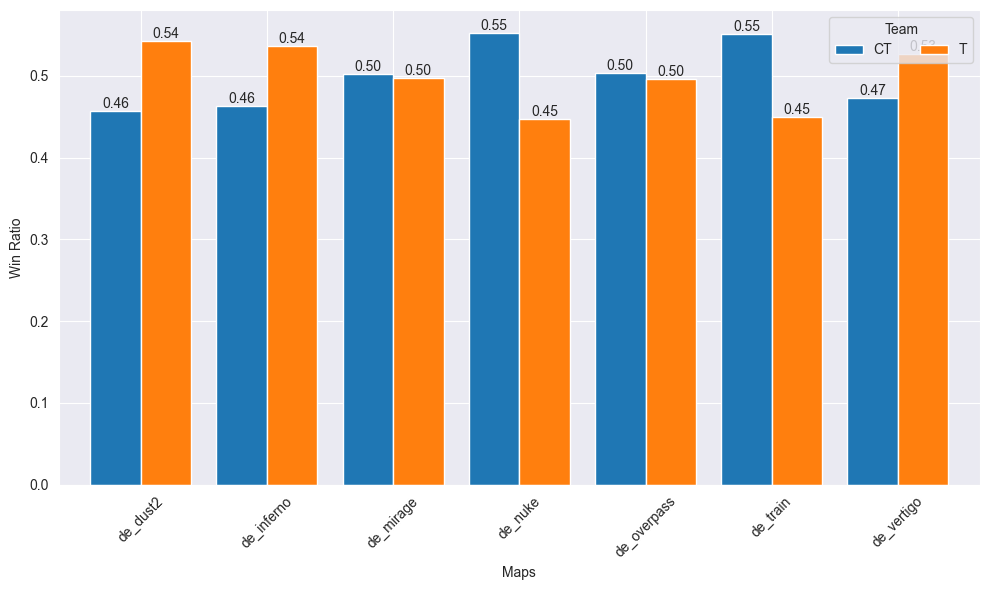

In [8]:
df = drop_row_data(df, 3, "map")

is_new_round = df['time_left'].diff() > 0

df['round_id'] = is_new_round.cumsum()

rounds_df = df.drop_duplicates(subset=['round_id'])

win_rates = pd.crosstab(rounds_df['map'], rounds_df['round_winner'], normalize='index')

fig, ax = plt.subplots(figsize=(10, 6))
win_rates[['CT', 'T']].plot(kind='bar', ax=ax, width=0.8)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

ax.set_ylabel("Win Ratio")
ax.set_xlabel("Maps")
ax.legend(title="Team", ncols=2)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
weapons = ['ct_weapon_ak47',
       't_weapon_ak47', 'ct_weapon_aug', 't_weapon_aug', 'ct_weapon_awp',
       't_weapon_awp', 'ct_weapon_bizon', 't_weapon_bizon',
       'ct_weapon_cz75auto', 't_weapon_cz75auto', 'ct_weapon_elite',
       't_weapon_elite', 'ct_weapon_famas', 't_weapon_famas',
       'ct_weapon_g3sg1', 't_weapon_g3sg1', 'ct_weapon_galilar',
       't_weapon_galilar', 'ct_weapon_glock', 't_weapon_glock',
       'ct_weapon_m249', 't_weapon_m249', 'ct_weapon_m4a1s',
       't_weapon_m4a1s', 'ct_weapon_m4a4', 't_weapon_m4a4',
       'ct_weapon_mac10', 't_weapon_mac10', 'ct_weapon_mag7',
       't_weapon_mag7', 'ct_weapon_mp5sd', 't_weapon_mp5sd',
       'ct_weapon_mp7', 't_weapon_mp7', 'ct_weapon_mp9', 't_weapon_mp9',
       'ct_weapon_negev', 't_weapon_negev', 'ct_weapon_nova',
       't_weapon_nova', 'ct_weapon_p90', 't_weapon_p90',
       'ct_weapon_r8revolver', 't_weapon_r8revolver',
       'ct_weapon_sawedoff', 't_weapon_sawedoff', 'ct_weapon_scar20',
       't_weapon_scar20', 'ct_weapon_sg553', 't_weapon_sg553',
       'ct_weapon_ssg08', 't_weapon_ssg08', 'ct_weapon_ump45',
       't_weapon_ump45', 'ct_weapon_xm1014', 't_weapon_xm1014',
       'ct_weapon_deagle', 't_weapon_deagle', 'ct_weapon_fiveseven',
       't_weapon_fiveseven', 'ct_weapon_usps', 't_weapon_usps',
       'ct_weapon_p250', 't_weapon_p250', 'ct_weapon_p2000',
       't_weapon_p2000', 'ct_weapon_tec9', 't_weapon_tec9']


# --- Counter-Terrorist (CT) Weapons ---

ct_rifles = [
    'ct_weapon_ak47', 'ct_weapon_aug', 'ct_weapon_famas', 
    'ct_weapon_galilar', 'ct_weapon_m4a1s', 'ct_weapon_m4a4', 
    'ct_weapon_sg553'
]
ct_mp = [
    'ct_weapon_bizon', 'ct_weapon_mac10', 'ct_weapon_mp5sd', 
    'ct_weapon_mp7', 'ct_weapon_mp9', 'ct_weapon_p90', 
    'ct_weapon_ump45', 'ct_weapon_m249', 'ct_weapon_negev'
]
ct_snipers = [
    'ct_weapon_awp', 'ct_weapon_g3sg1', 'ct_weapon_scar20', 
    'ct_weapon_ssg08'
]
ct_shotguns = [
    'ct_weapon_mag7', 'ct_weapon_nova', 'ct_weapon_sawedoff', 
    'ct_weapon_xm1014'
]
ct_spawn_pistols = [
    'ct_weapon_p2000', 'ct_weapon_usps'
]
ct_other_pistols = [
    'ct_weapon_cz75auto', 'ct_weapon_deagle', 'ct_weapon_elite', 
    'ct_weapon_fiveseven', 'ct_weapon_p250', 'ct_weapon_r8revolver', 
    'ct_weapon_glock', 'ct_weapon_tec9'
]

# --- Terrorist (T) Weapons ---

t_rifles = [
    't_weapon_ak47', 't_weapon_aug', 't_weapon_famas', 
    't_weapon_galilar', 't_weapon_m4a1s', 't_weapon_m4a4', 
    't_weapon_sg553'
]
t_mp = [
    't_weapon_bizon', 't_weapon_mac10', 't_weapon_mp5sd', 
    't_weapon_mp7', 't_weapon_mp9', 't_weapon_p90', 
    't_weapon_ump45', 't_weapon_m249', 't_weapon_negev'
]
t_snipers = [
    't_weapon_awp', 't_weapon_g3sg1', 't_weapon_scar20', 
    't_weapon_ssg08'
]
t_shotguns = [
    't_weapon_mag7', 't_weapon_nova', 't_weapon_sawedoff', 
    't_weapon_xm1014'
]
t_spawn_pistols = [
    't_weapon_glock'
]
t_other_pistols = [
    't_weapon_p2000', 't_weapon_usps', 't_weapon_tec9', 
    't_weapon_cz75auto', 't_weapon_deagle', 't_weapon_elite', 
    't_weapon_fiveseven', 't_weapon_p250', 't_weapon_r8revolver'
]


weapons_df = pd.DataFrame()
weapons_df["ct_rifles"] = df[ct_rifles].sum(axis=1)
weapons_df["ct_utility_weapon"] = df[ct_mp + ct_shotguns].sum(axis=1)
weapons_df["ct_snipers"] = df[ct_snipers].sum(axis=1)
weapons_df["ct_spawn_pistols"] = pd.to_numeric(df[df[ct_spawn_pistols] <= 5].sum(axis=1))
weapons_df["ct_other_pistols"] = df[ct_other_pistols].sum(axis=1)

weapons_df["t_rifles"] = df[t_rifles].sum(axis=1)
weapons_df["t_utility_weapon"] = df[t_mp + t_shotguns].sum(axis=1)
weapons_df["t_snipers"] = df[t_snipers].sum(axis=1)
weapons_df["t_spawn_pistols"] = df[t_spawn_pistols].sum(axis=1)
weapons_df["t_other_pistols"] = df[t_other_pistols].sum(axis=1)

grenades = ['ct_grenade_hegrenade', 't_grenade_hegrenade',
       'ct_grenade_flashbang', 't_grenade_flashbang',
       'ct_grenade_smokegrenade', 't_grenade_smokegrenade',
       'ct_grenade_incendiarygrenade', 't_grenade_incendiarygrenade',
       'ct_grenade_molotovgrenade', 't_grenade_molotovgrenade',]

weapons_df['ct_grenades'] = df[['ct_grenade_hegrenade', 'ct_grenade_flashbang', 'ct_grenade_smokegrenade', 'ct_grenade_incendiarygrenade', 'ct_grenade_molotovgrenade']].sum(axis=1)
weapons_df['t_grenades'] = df[['t_grenade_hegrenade', 't_grenade_flashbang', 't_grenade_smokegrenade', 't_grenade_incendiarygrenade', 't_grenade_molotovgrenade']].sum(axis=1)

In [10]:
final_df = weapons_df.copy()
final_df["time_left"] = df["time_left"]
final_df["ct_score"] = df["ct_score"]
final_df["t_score"] = df["t_score"]
final_df["bomb_planted"] = df["bomb_planted"]
final_df["ct_health"] = df["ct_health"]
final_df["t_health"] = df["t_health"]
final_df["ct_armor"] = df["ct_armor"]
final_df["t_armor"] = df["t_armor"]
final_df["ct_helmets"] = df["ct_helmets"]
final_df["t_helmets"] = df["t_helmets"]
final_df["ct_defuse_kits"] = df["ct_defuse_kits"]
final_df["ct_players_alive"] = df["ct_players_alive"]
final_df["t_players_alive"] = df["t_players_alive"]
final_df["round_winner"] = df["round_winner"]
final_df["map"] = df["map"]
final_df["round_id"] = df["round_id"]
final_df.describe()

,ct_rifles,ct_utility_weapon,ct_snipers,ct_spawn_pistols,ct_other_pistols,t_rifles,t_utility_weapon,t_snipers,t_spawn_pistols,t_other_pistols,...,ct_health,t_health,ct_armor,t_armor,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_id
count,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,...,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000,122265.000000
mean,1.909295,0.217544,0.633689,3.353323,0.909942,2.247389,0.155024,0.342396,3.310547,0.945299,...,412.112125,402.738273,314.103178,298.456778,2.052713,2.774326,1.613054,4.273692,4.266438,11859.012980
std,1.597391,0.593743,0.678954,1.615465,1.239955,1.784669,0.519870,0.488091,1.625857,1.246674,...,132.305448,139.899590,171.038788,174.571249,1.841191,2.011030,1.605786,1.205597,1.228154,6818.540406
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,...,350.000000,322.000000,194.000000,174.000000,0.000000,0.000000,0.000000,4.000000,4.000000,5927.000000
50%,2.000000,0.000000,1.000000,4.000000,0.000000,2.000000,0.000000,0.000000,4.000000,0.000000,...,500.000000,500.000000,377.000000,334.000000,2.000000,3.000000,1.000000,5.000000,5.000000,11913.000000
75%,3.000000,0.000000,1.000000,5.000000,1.000000,4.000000,0.000000,1.000000,5.000000,2.000000,...,500.000000,500.000000,486.000000,468.000000,4.000000,5.000000,3.000000,5.000000,5.000000,17814.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,9.000000,7.000000,...,500.000000,600.000000,500.000000,500.000000,5.000000,5.000000,5.000000,5.000000,6.000000,23508.000000


In [11]:
valid_mask = (
    (final_df['ct_players_alive'] <= 5) &
    (final_df['t_players_alive'] <= 5) &

    (final_df['ct_health'] <= 500) &
    (final_df['t_health'] <= 500) &
    (final_df['ct_armor'] <= 500) &
    (final_df['t_armor'] <= 500) &
    (final_df['ct_helmets'] <= 5) &
    (final_df['t_helmets'] <= 5) &

    (final_df['ct_defuse_kits'] <= 5) &

    ((final_df['ct_rifles'] + final_df['ct_snipers'] + final_df['ct_utility_weapon']) <= 5) &
    ((final_df['t_rifles'] + final_df['t_snipers'] + final_df['t_utility_weapon']) <= 5) &

    ((final_df['ct_spawn_pistols'] + final_df['ct_other_pistols']) <= 5) &
    ((final_df['t_spawn_pistols'] + final_df['t_other_pistols']) <= 5) &

    ((final_df['ct_grenades'] <= 25) & (final_df['t_grenades'] <= 25))
)

clean_df = final_df[valid_mask].copy()
clean_df.describe()

,ct_rifles,ct_utility_weapon,ct_snipers,ct_spawn_pistols,ct_other_pistols,t_rifles,t_utility_weapon,t_snipers,t_spawn_pistols,t_other_pistols,...,ct_health,t_health,ct_armor,t_armor,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_id
count,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,...,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000,122142.000000
mean,1.910891,0.217763,0.634270,3.352336,0.910268,2.249234,0.155155,0.342675,3.308993,0.945195,...,412.024439,402.640328,314.401320,298.729724,2.054666,2.776801,1.614588,4.272969,4.265699,11858.609373
std,1.597237,0.594001,0.679009,1.615302,1.240206,1.784486,0.520092,0.488195,1.625682,1.246648,...,132.342869,139.935361,170.847379,174.425452,1.840964,2.010271,1.605774,1.205985,1.228545,6818.335276
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,...,350.000000,321.000000,194.000000,175.000000,0.000000,0.000000,0.000000,4.000000,4.000000,5927.000000
50%,2.000000,0.000000,1.000000,4.000000,0.000000,2.000000,0.000000,0.000000,4.000000,0.000000,...,500.000000,500.000000,378.000000,335.000000,2.000000,3.000000,1.000000,5.000000,5.000000,11912.000000
75%,3.000000,0.000000,1.000000,5.000000,1.000000,4.000000,0.000000,1.000000,5.000000,2.000000,...,500.000000,500.000000,486.000000,468.000000,4.000000,5.000000,3.000000,5.000000,5.000000,17813.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,500.000000,500.000000,500.000000,500.000000,5.000000,5.000000,5.000000,5.000000,5.000000,23508.000000


In [12]:

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(clean_df, groups=clean_df["round_id"]))

train_set = clean_df.iloc[train_idx].copy()
test_set = clean_df.iloc[test_idx].copy()

In [13]:
ratio_est = RatioEstimator(df_with_ids=True)
train_ratio = ratio_est.fit(train_set, 'map', 'round_winner', 'round_id')
train_ratio

round_winner,CT,T
map,,
de_dust2,0.464772,0.535228
de_inferno,0.458356,0.541644
de_mirage,0.506272,0.493728
de_nuke,0.546068,0.453932
de_overpass,0.503308,0.496692
de_train,0.543091,0.456909
de_vertigo,0.473868,0.526132


In [14]:
train_set = pd.merge(train_set, train_ratio, on='map', how='left')
test_set = pd.merge(test_set, train_ratio, on='map', how='left')
test_set = test_set.fillna(0.50)
train_set

,ct_rifles,ct_utility_weapon,ct_snipers,ct_spawn_pistols,ct_other_pistols,t_rifles,t_utility_weapon,t_snipers,t_spawn_pistols,t_other_pistols,...,ct_helmets,t_helmets,ct_defuse_kits,ct_players_alive,t_players_alive,round_winner,map,round_id,CT,T
0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,5.0,5.0,CT,de_dust2,0,0.464772,0.535228
1,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,1.0,5.0,5.0,CT,de_dust2,0,0.464772,0.535228
2,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,1.0,4.0,4.0,CT,de_dust2,0,0.464772,0.535228
3,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,3.0,1.0,...,0.0,0.0,1.0,4.0,4.0,CT,de_dust2,0,0.464772,0.535228
4,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,1.0,5.0,5.0,CT,de_dust2,1,0.464772,0.535228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97877,1.0,1.0,0.0,2.0,0.0,3.0,0.0,1.0,2.0,2.0,...,2.0,4.0,1.0,2.0,4.0,T,de_train,23507,0.543091,0.456909
97878,1.0,0.0,0.0,5.0,0.0,1.0,0.0,1.0,5.0,0.0,...,1.0,2.0,1.0,5.0,5.0,T,de_train,23508,0.543091,0.456909
97879,1.0,0.0,0.0,1.0,4.0,3.0,0.0,1.0,4.0,1.0,...,3.0,5.0,1.0,5.0,5.0,T,de_train,23508,0.543091,0.456909
97880,1.0,0.0,0.0,1.0,4.0,4.0,0.0,1.0,4.0,1.0,...,3.0,5.0,1.0,5.0,5.0,T,de_train,23508,0.543091,0.456909


In [15]:
cols_to_drop = ["ct_grenades", "t_utility_weapon", "ct_spawn_pistols", "t_spawn_pistols", "ct_utility_weapon", "ct_other_pistols", "ct_score", "t_snipers", "t_score", "t_grenades", "t_other_pistols", 'map', 'round_winner', 'round_id']

mm_scaler = MinMaxScaler(clip=True)

scaler_filter = [col for col in train_set.columns if col not in cols_to_drop]

train_set[scaler_filter] = mm_scaler.fit_transform(train_set[scaler_filter])
test_set[scaler_filter] = mm_scaler.transform(test_set[scaler_filter])
train_set.describe()
mm_scaler

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",True


In [16]:
label_map = {
    "CT" : 1,
    "T": 0
}
X_train = train_set.drop(columns=cols_to_drop)
y_train = train_set['round_winner'].copy().map(label_map)
X_test = test_set.drop(columns=cols_to_drop)
y_test = test_set['round_winner'].copy().map(label_map)

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

metrics_report = []

for model_name, model in models.items():
    start_time = time.time()
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    train_time = time.time() - start_time
    
    metrics_report.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (CT)": precision_score(y_test, y_pred),
        "Recall (CT)": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": round(train_time, 2)
    })

report_df = pd.DataFrame(metrics_report)

report_df = report_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)


print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

              Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
  Gradient Boosting    0.7535          0.7356       0.7792    0.7568   0.8550      9.3700
Logistic Regression    0.7484          0.7393       0.7549    0.7470   0.8410      0.1600
      Random Forest    0.7399          0.7338       0.7399    0.7368   0.8403      1.7800


C:\Users\rodio\AppData\Local\Temp\ipykernel_10200\1088389184.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', ax=ax, palette='mako')


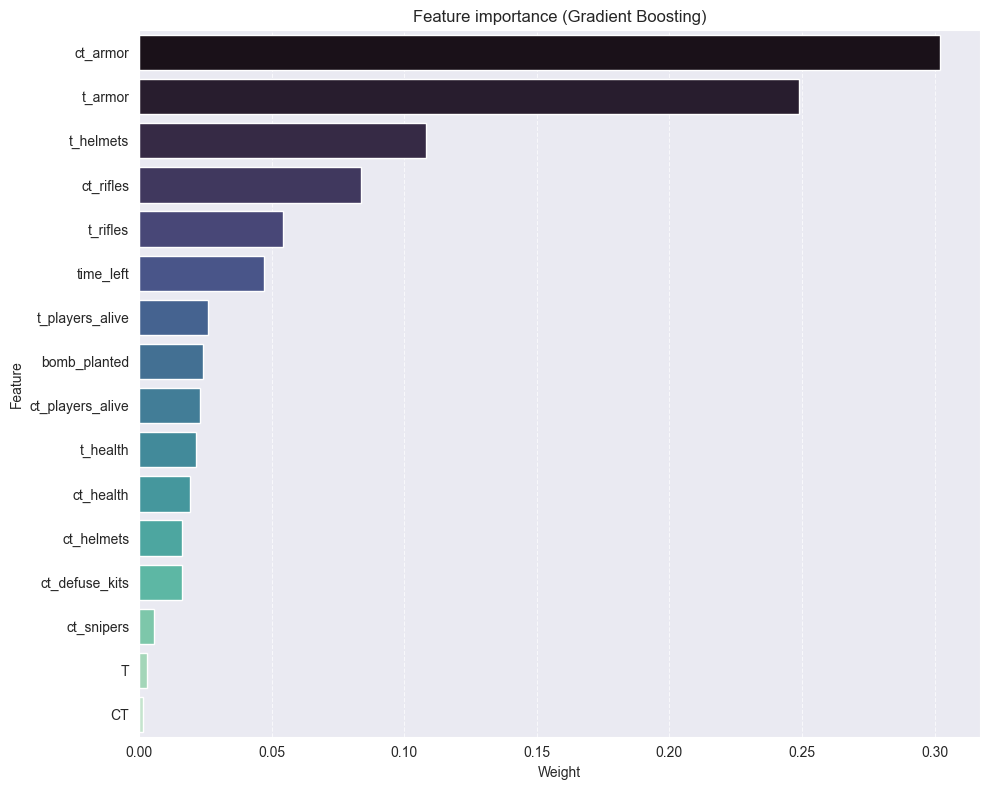

         Feature  Importance
        ct_armor    0.302040
         t_armor    0.248705
       t_helmets    0.108366
       ct_rifles    0.083527
        t_rifles    0.054114
       time_left    0.047034
 t_players_alive    0.025979
    bomb_planted    0.024108
ct_players_alive    0.022822
        t_health    0.021594
       ct_health    0.019237
      ct_helmets    0.016164
  ct_defuse_kits    0.016067
      ct_snipers    0.005733
               T    0.002915
              CT    0.001594


In [18]:
model_for_importance = models["Gradient Boosting"]

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_for_importance.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importances, x='Importance', y='Feature', ax=ax, palette='mako')

ax.set_title("Feature importance (Gradient Boosting)")
ax.set_xlabel("Weight")
ax.set_ylabel("Feature")
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(importances[importances['Importance'] < 100].to_string(index=False))

In [20]:
clean_df["round_winner"].value_counts(normalize=True)

round_winner
T     0.510128
CT    0.489872
Name: proportion, dtype: float64